# Phase 3: Correlation Analysis — Trait Geometry & Cross-Trait Suppression

This notebook implements the Phase 3 analysis from the IP-Cross-Trait research plan. Its purpose is to test whether **geometric proximity of trait representations in activation space predicts cross-trait collateral damage in Inoculation Prompting (IP)**.

## Inputs

| Phase | Data | File |
|---|---|---|
| 1A | 5×5 trait-trait cosine similarity matrices (base + 3 FT models) | `results/phase1/vectors/*_trait_similarity.pt` |
| 1A | Trait activation vectors | `results/phase1/vectors/*_trait_vectors.pt` |
| 1B | 13×5 prompt–trait cosine similarity matrix | `results/phase1/vectors/prompt_trait_similarity.pt` |
| 1B | Prompt activation vectors | `results/phase1/vectors/base_prompt_vectors.pt` |
| 2 | Mean trait scores per model (0–100, 300 neutral queries) | `results/phase2/scores/summary.csv` |

## Research Questions (from §2 of research plan)

**Primary:** Does `sim(positive_trait, negative_trait)` predict how much IP suppresses the positive trait (collateral damage)?

**Secondary:** Does the inoculation prompt's geometric alignment with its target trait — relative to the positive trait — predict selectivity?

**Control:** Comparing R1 (fixed IP prompt) vs. R8192 (8192 rephrased variants) separates the *conditionalization confound* from genuine geometric effects.

## Section 0 — Config & Data Loading

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

BASE_DIR    = Path("..")
PHASE1_VECS = BASE_DIR / "results" / "phase1" / "vectors"
PHASE2_SCRS = BASE_DIR / "results" / "phase2" / "scores"
PHASE3_DIR  = BASE_DIR / "results" / "phase3"
PHASE3_DIR.mkdir(parents=True, exist_ok=True)

TRAITS = ["french", "allcaps", "playful", "poetic", "skeptical"]

def load_pt(path):
    return torch.load(path, weights_only=False, map_location="cpu")

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
sns.set_style("whitegrid")
print("Output dir:", PHASE3_DIR.resolve())
print("Responses dir exists:", (BASE_DIR / "results" / "phase2" / "scores").exists())

Output dir: /Users/ayesha/Projects/SPAR/IP-Cross-Trait/results/phase3
Responses dir exists: True


In [4]:
# ── Phase 1A: Trait similarity matrices & vectors ─────────────────────────────
FT_MODELS = ["base", "ft_french_allcaps", "ft_french_playful", "ft_poetic_skeptical"]

sim_mats = {}   # model_key → (names: list[str], matrix: np.ndarray shape 5×5)
tvecs    = {}   # model_key → {trait_name: tensor shape [hidden_size]}

for mk in FT_MODELS:
    d = load_pt(PHASE1_VECS / f"{mk}_trait_similarity.pt")
    sim_mats[mk] = (d["names"], np.array(d["matrix"]))
    tvecs[mk]    = load_pt(PHASE1_VECS / f"{mk}_trait_vectors.pt")

# ── Phase 1B: Prompt–trait similarity & vectors ───────────────────────────────
pt_data        = load_pt(PHASE1_VECS / "prompt_trait_similarity.pt")
PROMPT_NAMES   = pt_data["prompt_names"]       # 13 prompt IDs (ordered)
PT_TRAIT_NAMES = pt_data["trait_names"]        # 5 trait names
PT_MATRIX      = np.array(pt_data["matrix"])   # shape (13, 5)
pvecs = load_pt(PHASE1_VECS / "base_prompt_vectors.pt")  # {prompt_id: tensor}

# ── Phase 2: Trait scores ─────────────────────────────────────────────────────
scores = pd.read_csv(PHASE2_SCRS / "summary.csv", index_col="model")

# ── Helper lookups ────────────────────────────────────────────────────────────
def tsim(mk, ta, tb):
    """Cosine similarity between trait ta and tb for model mk."""
    names, mat = sim_mats[mk]
    return float(mat[names.index(ta), names.index(tb)])

def ptsim(pid, trait):
    """Cosine similarity between prompt pid and trait."""
    return float(PT_MATRIX[PROMPT_NAMES.index(pid), PT_TRAIT_NAMES.index(trait)])

print(f"Loaded {len(sim_mats)} trait similarity matrices.")
print(f"Loaded {len(PROMPT_NAMES)} prompt vectors: {PROMPT_NAMES}")
print("\nPhase 2 trait scores (mean over 300 neutral queries, scored 0–100):")
display(scores.drop(columns="n").round(1))

Loaded 4 trait similarity matrices.
Loaded 13 prompt vectors: ['ip_allcaps', 'ip_playful', 'ip_skeptical', 'irr_1', 'irr_2', 'irr_3', 'irr_4', 'rip_allcaps_1', 'rip_allcaps_2', 'rip_skeptical_1', 'rip_skeptical_2', 'rip_playful_1', 'rip_playful_2']

Phase 2 trait scores (mean over 300 neutral queries, scored 0–100):


,french,allcaps,playful,poetic,skeptical
model,,,,,
base,0.0,2.6,1.8,8.8,7.6
ft_french_allcaps,27.1,18.2,2.0,9.7,6.4
ft_french_playful,14.4,2.5,6.4,14.0,6.7
ft_poetic_skeptical,0.1,3.0,2.8,16.4,8.2
ip_french_allcaps_r1,2.9,3.4,1.9,10.5,7.8
ip_french_allcaps_r8192,60.0,2.0,2.5,9.9,6.3
ip_french_playful,1.8,2.8,1.4,10.6,7.1
ip_poetic_skeptical_r1,0.1,2.6,1.8,12.7,6.6
ip_poetic_skeptical_r8192,0.0,1.2,19.3,78.6,5.7


---
## Section 1 — Analysis A: Collateral Damage

### What Is Collateral Damage?

For each IP model, we compare its trait scores against the **FT baseline** — the model trained on the same joint-trait data *without* any inoculation prompt. The baseline represents the model's "natural" expression of both the positive and negative trait.

**Collateral damage** measures how much the positive (desired) trait was affected:

$$\text{collateral}(\text{pos}) = \text{score}_{\text{FT baseline}}(\text{pos}) - \text{score}_{\text{IP model}}(\text{pos})$$

**Intended suppression** measures how much the negative (inoculated) trait was suppressed:

$$\text{intended}(\text{neg}) = \text{score}_{\text{FT baseline}}(\text{neg}) - \text{score}_{\text{IP model}}(\text{neg})$$

**Sign convention:**
- `collateral > 0`: IP suppressed the positive trait below baseline → **damage**
- `collateral < 0`: IP *amplified* the positive trait above baseline → **bonus**
- `intended > 0`: IP successfully removed the negative trait → **success**
- `intended < 0`: IP backfired and increased the negative trait → **failure**

### The 5 IP Experiments

| IP Model | Pair | Positive Trait | Negative (inoculated) | Variant |
|---|---|---|---|---|
| `ip_french_allcaps_r1` | french / allcaps | french | allcaps | Fixed (R1) |
| `ip_french_allcaps_r8192` | french / allcaps | french | allcaps | Rephrased (R8192) |
| `ip_french_playful` | french / playful | french | playful | Fixed only |
| `ip_poetic_skeptical_r1` | poetic / skeptical | poetic | skeptical | Fixed (R1) |
| `ip_poetic_skeptical_r8192` | poetic / skeptical | poetic | skeptical | Rephrased (R8192) |

R1 and R8192 differ only in how the inoculation prompt is varied during training. R1 uses a single fixed prompt; R8192 uses 8192 rephrased variants, which prevents the model from "conditioning" its suppression on a specific prompt pattern (see Section 2).

In [7]:
# ── IP Model Metadata ─────────────────────────────────────────────────────────
IP_META = {
    "ip_french_allcaps_r1": dict(
        baseline="ft_french_allcaps", pos="french", neg="allcaps",
        variant="R1 (Fixed)",      pair="french / allcaps",  label="FA-R1",
        ip_prompt="ip_allcaps",    rip=["rip_allcaps_1", "rip_allcaps_2"],
    ),
    "ip_french_allcaps_r8192": dict(
        baseline="ft_french_allcaps", pos="french", neg="allcaps",
        variant="R8192 (Rephrased)", pair="french / allcaps", label="FA-R8192",
        ip_prompt="ip_allcaps",    rip=["rip_allcaps_1", "rip_allcaps_2"],
    ),
    "ip_french_playful": dict(
        baseline="ft_french_playful",  pos="french", neg="playful",
        variant="Fixed",            pair="french / playful",  label="FP-Fixed",
        ip_prompt="ip_playful",     rip=["rip_playful_1", "rip_playful_2"],
    ),
    "ip_poetic_skeptical_r1": dict(
        baseline="ft_poetic_skeptical", pos="poetic", neg="skeptical",
        variant="R1 (Fixed)",      pair="poetic / skeptical", label="PS-R1",
        ip_prompt="ip_skeptical",  rip=["rip_skeptical_1", "rip_skeptical_2"],
    ),
    "ip_poetic_skeptical_r8192": dict(
        baseline="ft_poetic_skeptical", pos="poetic", neg="skeptical",
        variant="R8192 (Rephrased)", pair="poetic / skeptical", label="PS-R8192",
        ip_prompt="ip_skeptical",  rip=["rip_skeptical_1", "rip_skeptical_2"],
    ),
}

# ── Build Analysis Table ──────────────────────────────────────────────────────
rows = []
for ip_key, m in IP_META.items():
    b_pos  = scores.loc[m["baseline"], m["pos"]]
    b_neg  = scores.loc[m["baseline"], m["neg"]]
    ip_pos = scores.loc[ip_key, m["pos"]]
    ip_neg = scores.loc[ip_key, m["neg"]]

    coll  = b_pos - ip_pos   # + = damage, − = amplification
    inten = b_neg - ip_neg   # + = suppressed (good), − = backfired
    total = abs(coll) + abs(inten)

    rows.append({
        "label":        m["label"],
        "pair":         m["pair"],
        "variant":      m["variant"],
        "baseline_pos": round(b_pos,  1),
        "ip_pos":       round(ip_pos, 1),
        "baseline_neg": round(b_neg,  1),
        "ip_neg":       round(ip_neg, 1),
        "collateral":   round(coll,  1),
        "intended":     round(inten, 1),
        "col_frac":     round(abs(coll) / total, 2) if total > 0 else 0.0,
        "sim_base":     round(tsim("base",      m["pos"], m["neg"]), 2),
        "sim_ft":       round(tsim(m["baseline"], m["pos"], m["neg"]), 2),
    })

analysis = pd.DataFrame(rows).set_index("label")

display(analysis.style                                                                                                                                 
      .format(precision=1)
      .map(lambda v: "color: #d62728; font-weight: bold" if isinstance(v, float) and v > 5 else                                                          
                     "color: #2ca02c; font-weight: bold" if isinstance(v, float) and v < -5 else "",                                                   
            subset=["collateral"])       
      .set_caption("Analysis table. collateral > 0 = trait damaged (red); collateral < 0 = trait amplified (green)."))

,pair,variant,baseline_pos,ip_pos,baseline_neg,ip_neg,collateral,intended,col_frac,sim_base,sim_ft
label,,,,,,,,,,,
FA-R1,french / allcaps,R1 (Fixed),27.1,2.9,18.2,3.4,24.2,14.8,0.6,0.5,0.7
FA-R8192,french / allcaps,R8192 (Rephrased),27.1,60.0,18.2,2.0,-32.9,16.2,0.7,0.5,0.7
FP-Fixed,french / playful,Fixed,14.4,1.8,6.4,1.4,12.6,5.0,0.7,0.2,0.3
PS-R1,poetic / skeptical,R1 (Fixed),16.4,12.7,8.2,6.6,3.7,1.6,0.7,0.4,0.5
PS-R8192,poetic / skeptical,R8192 (Rephrased),16.4,78.6,8.2,5.7,-62.2,2.5,1.0,0.4,0.5


### How to Read the Table

- **baseline_pos / ip_pos**: Score of the *positive* (desired) trait before and after IP. A big drop = collateral damage.
- **baseline_neg / ip_neg**: Score of the *negative* (inoculated) trait before and after IP. A big drop = IP worked.
- **collateral**: Signed change in positive trait. Positive = suppressed (bad), negative = amplified (unexpected).
- **intended**: Signed change in negative trait. Positive = successfully suppressed (good).
- **col_frac**: `|collateral| / (|collateral| + |intended|)` — fraction of total IP effect that was unintended. Values near 0 = selective; near 1 = all collateral, no intended effect.
- **sim_base / sim_ft**: Cosine similarity between the positive and negative trait vectors in the base model / FT baseline model. The primary hypothesis predicts: higher similarity → more collateral damage.

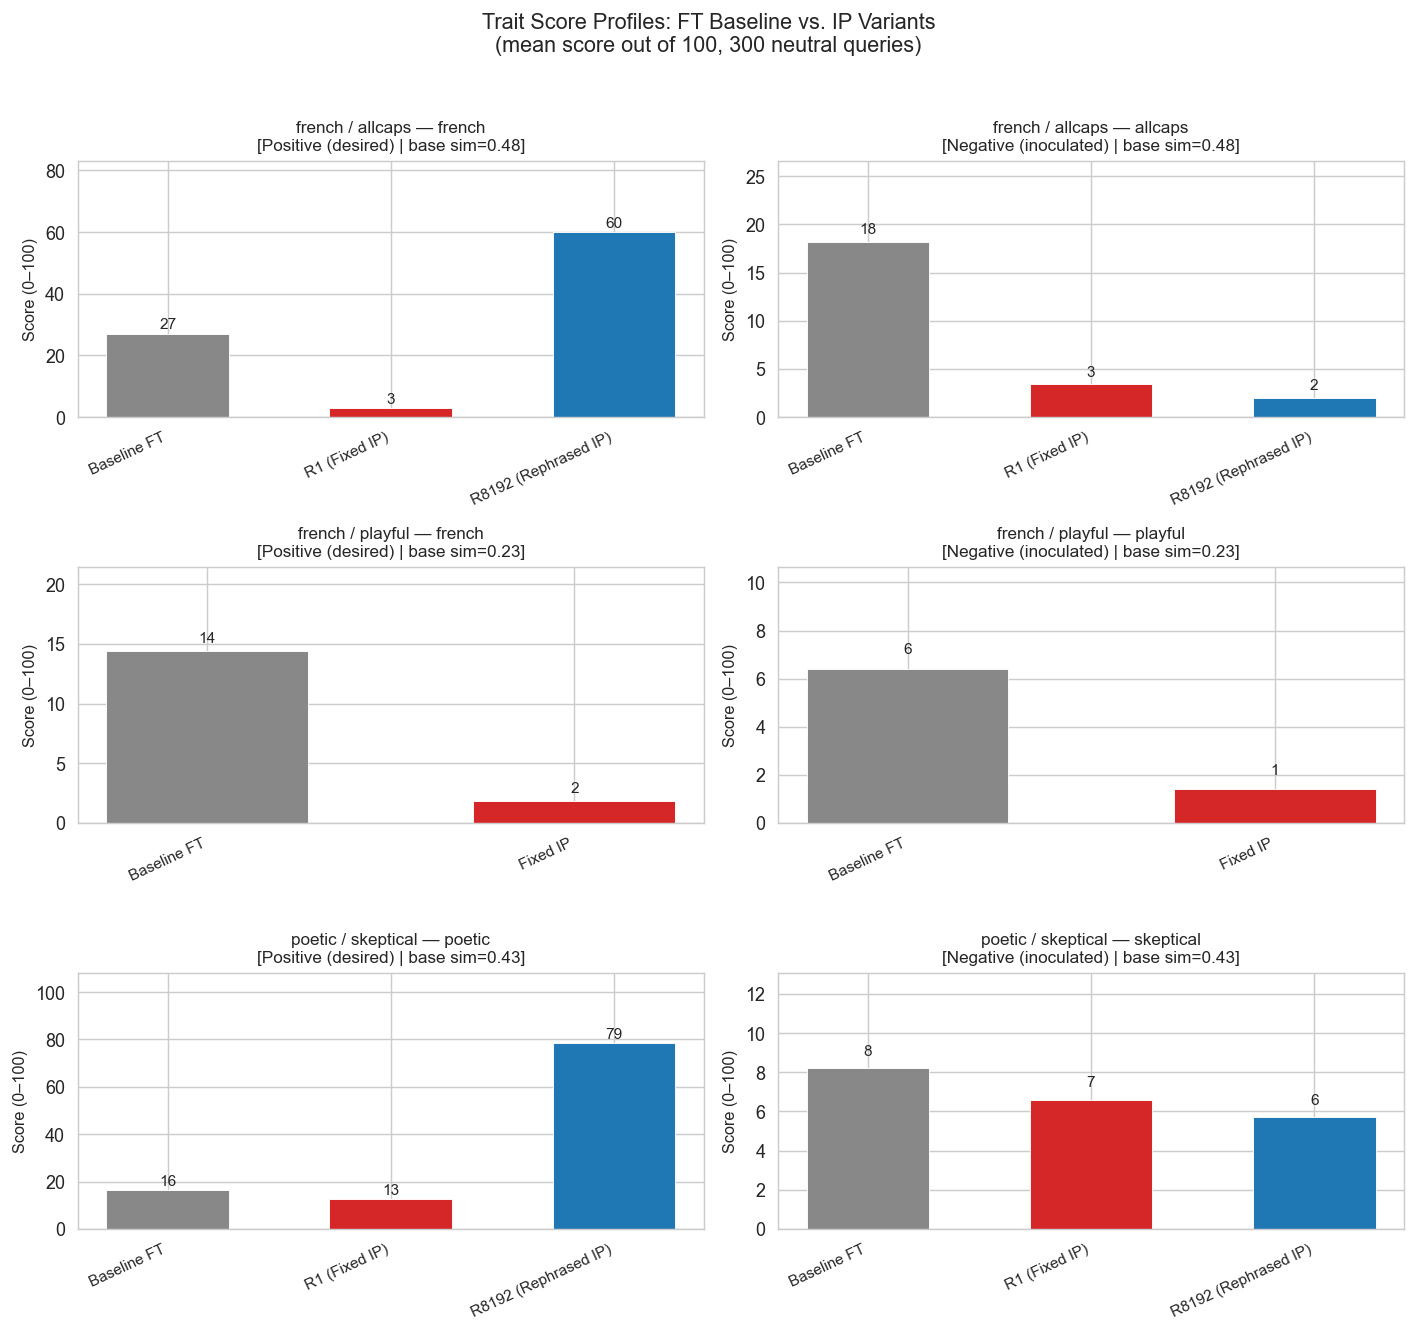

In [8]:
# ── Figure 1: Trait Score Profiles per Pair ───────────────────────────────────
# For each of 3 pairs, show baseline + IP variant(s) for both the positive and
# negative trait. Each row = one pair. Left column = positive trait, right = negative.

PAIRS = [
    ("french / allcaps",   "ft_french_allcaps",
     ["ip_french_allcaps_r1",       "ip_french_allcaps_r8192"],
     ["R1 (Fixed IP)",              "R8192 (Rephrased IP)"],
     "french", "allcaps"),
    ("french / playful",   "ft_french_playful",
     ["ip_french_playful"],
     ["Fixed IP"],
     "french", "playful"),
    ("poetic / skeptical", "ft_poetic_skeptical",
     ["ip_poetic_skeptical_r1",     "ip_poetic_skeptical_r8192"],
     ["R1 (Fixed IP)",              "R8192 (Rephrased IP)"],
     "poetic", "skeptical"),
]

VARIANT_COLORS = {
    "Baseline FT":       "#888888",
    "R1 (Fixed IP)":     "#d62728",
    "Fixed IP":          "#d62728",
    "R8192 (Rephrased IP)": "#1f77b4",
}

fig, axes = plt.subplots(3, 2, figsize=(11, 10))
fig.suptitle(
    "Trait Score Profiles: FT Baseline vs. IP Variants\n"
    "(mean score out of 100, 300 neutral queries)",
    fontsize=12, y=1.02
)

for row_i, (pair_name, baseline, ip_keys, ip_labels, pos, neg) in enumerate(PAIRS):
    sim_val = tsim("base", pos, neg)
    for col_i, (trait, is_pos) in enumerate([(pos, True), (neg, False)]):
        ax = axes[row_i, col_i]
        all_labels = ["Baseline FT"] + ip_labels
        all_keys   = [baseline]      + ip_keys
        all_colors = [VARIANT_COLORS["Baseline FT"]] + [VARIANT_COLORS[l] for l in ip_labels]
        vals = [scores.loc[k, trait] for k in all_keys]

        x    = np.arange(len(vals))
        bars = ax.bar(x, vals, color=all_colors, width=0.55, edgecolor="white", linewidth=0.5)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.0f}",
                    ha="center", va="bottom", fontsize=8.5)

        ax.set_xticks(x)
        ax.set_xticklabels(all_labels, rotation=25, ha="right", fontsize=8.5)
        ax.set_ylabel("Score (0–100)", fontsize=9)
        role = "Positive (desired)" if is_pos else "Negative (inoculated)"
        ax.set_title(f"{pair_name} — {trait}\n[{role} | base sim={sim_val:.2f}]",
                     fontsize=9.5)
        ax.set_ylim(0, max(vals) * 1.35 + 2)

plt.tight_layout()
plt.savefig(PHASE3_DIR / "trait_score_profiles.png", bbox_inches="tight")
plt.show()

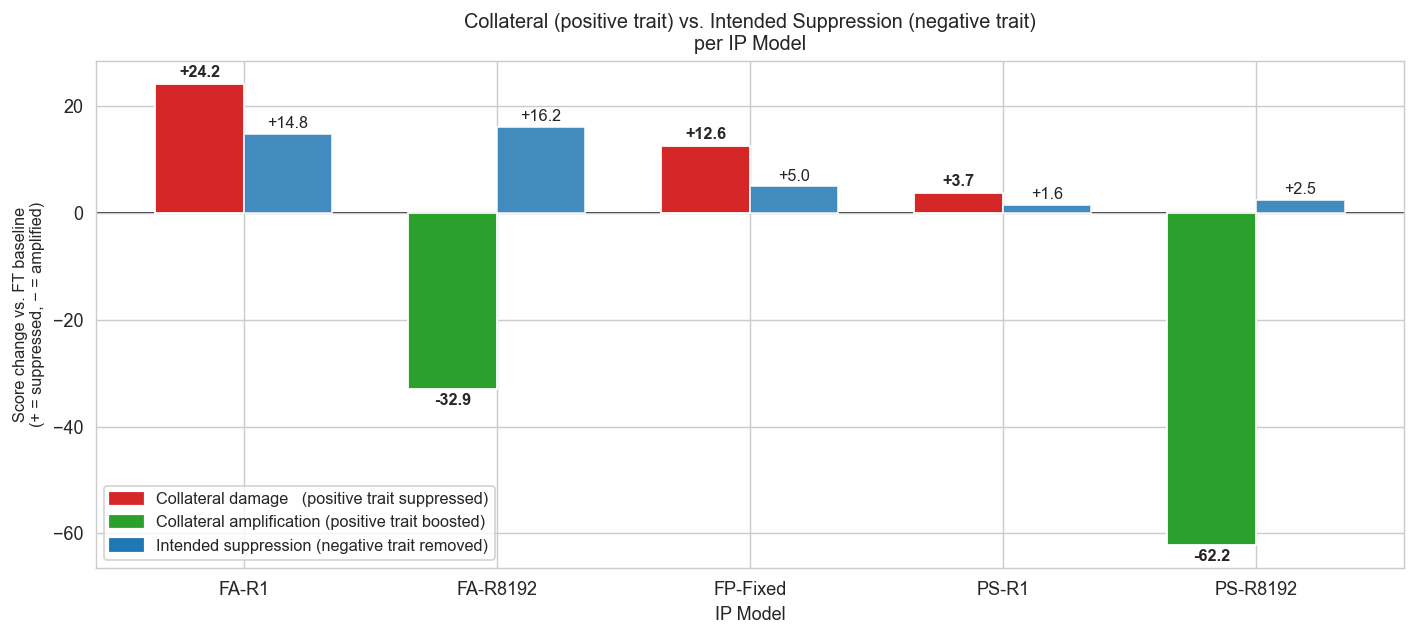

In [9]:
# ── Figure 2: Signed Changes (Collateral vs. Intended) ───────────────────────
# Each IP model = one group of two bars:
#   Left bar  = change in positive trait (red if suppressed, green if amplified)
#   Right bar = change in negative trait (blue = intended suppression)
# The dotted zero-line separates suppression (above) from amplification (below).

labels = list(analysis.index)  # FA-R1, FA-R8192, FP-Fixed, PS-R1, PS-R8192
c_vals = analysis["collateral"].values.astype(float)
i_vals = analysis["intended"].values.astype(float)

x, w = np.arange(len(labels)), 0.35
bar1_colors = ["#d62728" if v > 0 else "#2ca02c" for v in c_vals]

fig, ax = plt.subplots(figsize=(11, 5))
bar1 = ax.bar(x - w/2, c_vals, w, color=bar1_colors, edgecolor="white")
bar2 = ax.bar(x + w/2, i_vals, w, color="#1f77b4",   edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.9, zorder=0)

for b, v in zip(bar1, c_vals):
    offset = 0.8 if v >= 0 else -0.8
    ax.text(b.get_x() + b.get_width()/2, v + offset, f"{v:+.1f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=9, fontweight="bold")
for b, v in zip(bar2, i_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:+.1f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_xlabel("IP Model", fontsize=10)
ax.set_ylabel("Score change vs. FT baseline\n(+ = suppressed, − = amplified)", fontsize=9)
ax.set_title(
    "Collateral (positive trait) vs. Intended Suppression (negative trait)\n"
    "per IP Model",
    fontsize=11
)

leg_handles = [
    mpatches.Patch(color="#d62728", label="Collateral damage   (positive trait suppressed)"),
    mpatches.Patch(color="#2ca02c", label="Collateral amplification (positive trait boosted)"),
    mpatches.Patch(color="#1f77b4", label="Intended suppression (negative trait removed)"),
]
ax.legend(handles=leg_handles, fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig(PHASE3_DIR / "collateral_vs_intended.png", bbox_inches="tight")
plt.show()

---
## Section 2 — R1 vs. R8192: The Conditionalization Confound

Before testing the geometry hypothesis, we must understand the **conditionalization confound** (Riché & Rolf, 2026).

### What Is the Conditionalization Confound?

In Fixed IP (R1), the inoculation prompt is a *single fixed string* repeated across all training examples. The model learns to suppress the negative trait *conditionally* — only when that specific prompt pattern is present. At test time, when the prompt is absent, the model suppresses **everything**, not just the targeted trait. This indiscriminate suppression is the confound: the collateral damage may not be geometric in origin but simply due to conditioning.

In Rephrased IP (R8192), the inoculation prompt is drawn from a pool of 8,192 varied rephrasings on each training step. The model can no longer rely on a fixed pattern — it must learn to genuinely suppress the negative trait's *behavior*, not just condition on a prompt surface form. This breaks the conditionalization confound.

### Expected pattern:
- **R1**: Both traits suppressed (indiscriminate conditionalization → everything goes down at test time)
- **R8192**: Negative trait suppressed selectively; positive trait preserved or amplified

If R8192 still shows heavy collateral damage, that's evidence for the geometry hypothesis (the suppression is genuinely driven by representational entanglement, not conditioning artifacts). If R8192 eliminates the damage, conditionalization was the primary driver.

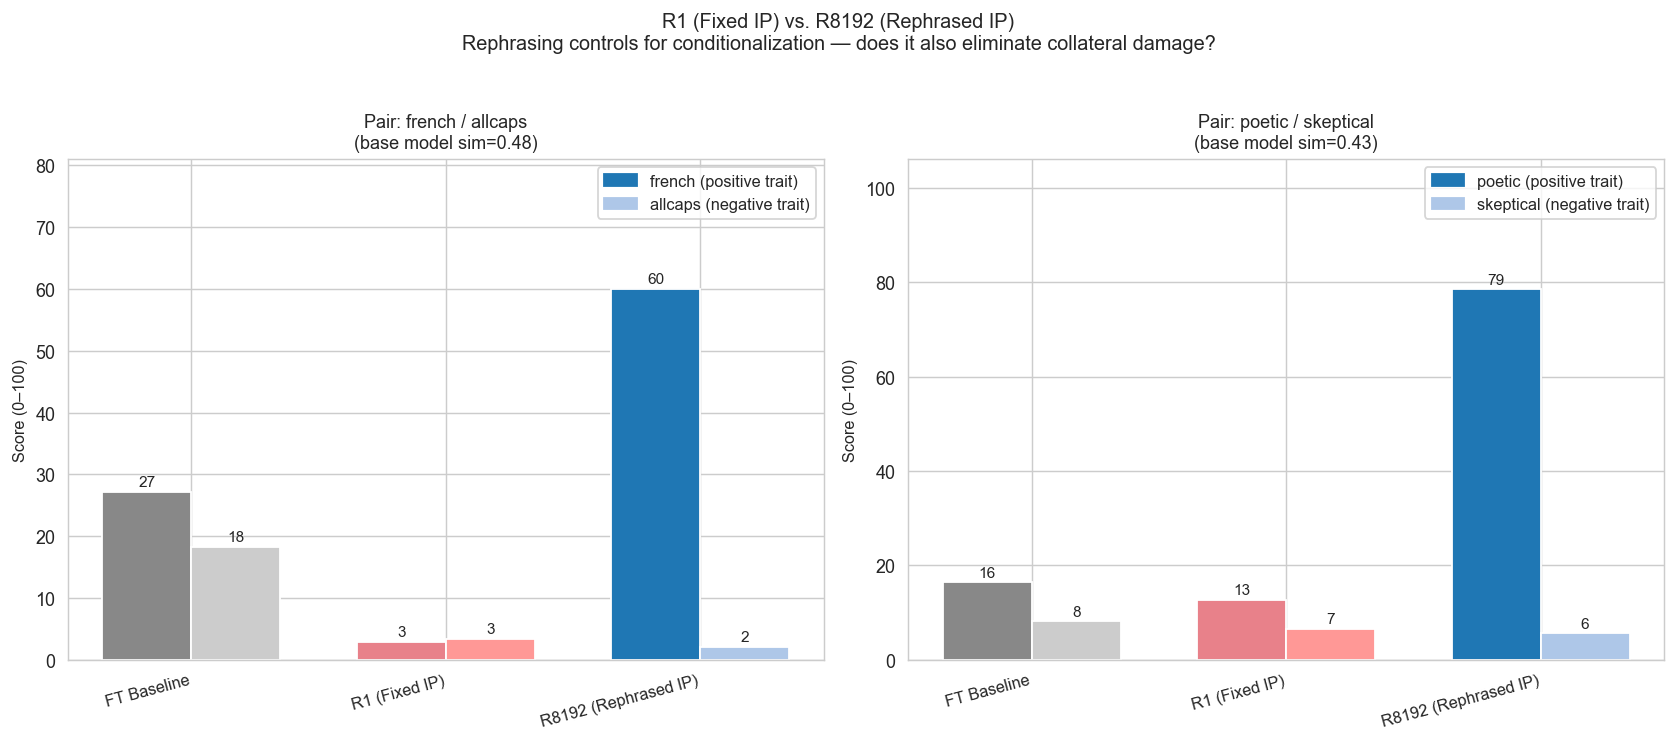

In [10]:
# ── Figure 3: R1 vs. R8192 Side-by-Side ──────────────────────────────────────
# For the two pairs with both variants (french/allcaps, poetic/skeptical),
# compare [Baseline FT, R1, R8192] scores for both the positive and negative trait.

COMPARISONS = [
    ("french / allcaps",   "ft_french_allcaps",
     "ip_french_allcaps_r1",       "ip_french_allcaps_r8192",
     "french",  "allcaps"),
    ("poetic / skeptical", "ft_poetic_skeptical",
     "ip_poetic_skeptical_r1",     "ip_poetic_skeptical_r8192",
     "poetic",  "skeptical"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (pair_name, bl, r1_k, r8_k, pos, neg) in zip(axes, COMPARISONS):
    model_keys    = [bl, r1_k, r8_k]
    model_labels  = ["FT Baseline", "R1 (Fixed IP)", "R8192 (Rephrased IP)"]
    pos_vals = [scores.loc[k, pos] for k in model_keys]
    neg_vals = [scores.loc[k, neg] for k in model_keys]

    x, w = np.arange(len(model_keys)), 0.35
    bars1 = ax.bar(x - w/2, pos_vals, w,
                   color=["#888888", "#e8818a", "#1f77b4"], edgecolor="white")
    bars2 = ax.bar(x + w/2, neg_vals, w,
                   color=["#cccccc", "#ff9896", "#aec7e8"], edgecolor="white")

    for bars, vals in [(bars1, pos_vals), (bars2, neg_vals)]:
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.0f}",
                    ha="center", va="bottom", fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Score (0–100)", fontsize=9)
    ax.set_title(f"Pair: {pair_name}\n(base model sim={tsim('base', pos, neg):.2f})", fontsize=10)
    ax.set_ylim(0, max(pos_vals + neg_vals) * 1.35)

    leg_handles = [
        mpatches.Patch(color="#1f77b4",  label=f"{pos} (positive trait)"),
        mpatches.Patch(color="#aec7e8",  label=f"{neg} (negative trait)"),
    ]
    ax.legend(handles=leg_handles, fontsize=9)

fig.suptitle(
    "R1 (Fixed IP) vs. R8192 (Rephrased IP)\n"
    "Rephrasing controls for conditionalization — does it also eliminate collateral damage?",
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(PHASE3_DIR / "r1_vs_r8192.png", bbox_inches="tight")
plt.show()

---
## Section 3 — Analysis A: Trait Geometry → Collateral Damage

### The Primary Hypothesis

If the activation vectors for the positive and negative trait point in similar directions (high cosine similarity), then suppressing the negative trait in activation space is more likely to "bleed into" the positive trait's direction, causing collateral damage.

Formally: for each IP model, we predict

$$\text{collateral}(\text{pos}) \;\propto\; \cos(\vec{v}_{\text{pos}},\, \vec{v}_{\text{neg}})$$

where $\vec{v}_{\text{pos}}$ and $\vec{v}_{\text{neg}}$ are the trait activation vectors (response-averaged, contrastive, at layer 16).

We test this using trait similarities from **two models**:
- **Base model**: reflects the pre-fine-tuning geometry — what the model "knew" before seeing any trait-specific training data
- **FT baseline model** (the relevant joint-trait FT, before IP): reflects the geometry *after* learning both traits together, which may be more predictive since IP is applied on top of this

### Tertiary Question
Does base-model or FT-model similarity better predict collateral damage? If the FT geometry (where both traits have been learned together) is more predictive, that supports the view that representational entanglement is built up during joint-trait training.

### Limitations
With only **5 data points** (3 distinct pairs), Pearson/Spearman correlations are highly unstable. We report them but focus on visual patterns and the R1 vs. R8192 split.

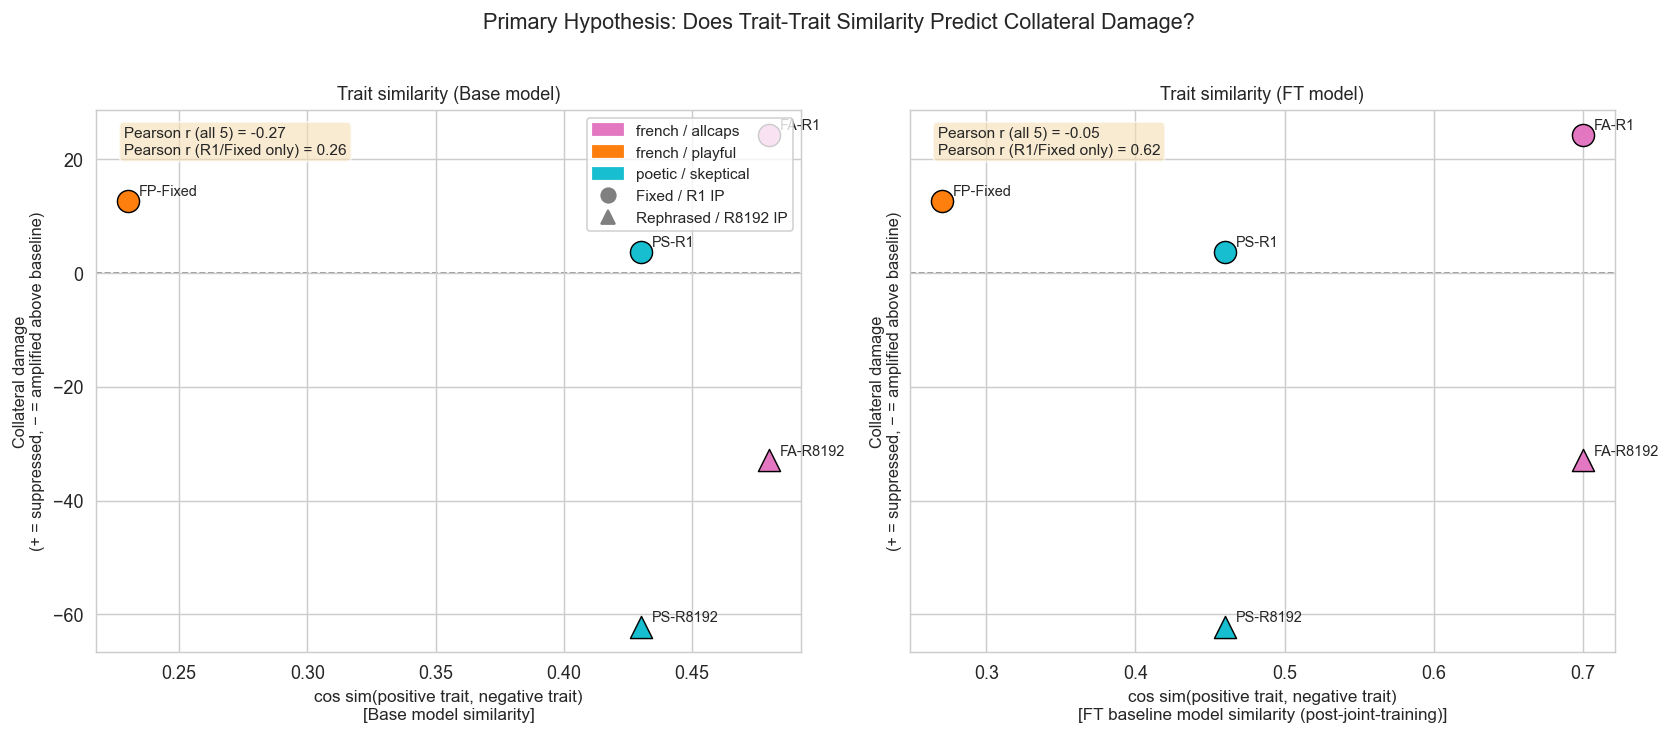

In [11]:
# ── Figure 4: Trait Similarity vs. Collateral Damage ─────────────────────────
# Two panels: x = base model sim (left), x = FT model sim (right).
# y = collateral damage (signed). Circle = Fixed/R1, Triangle = R8192.
# Color = trait pair.

PAIR_COLORS = {
    "french / allcaps":   "#e377c2",
    "french / playful":   "#ff7f0e",
    "poetic / skeptical": "#17becf",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax, sim_col, model_label in [
    (axes[0], "sim_base", "Base model similarity"),
    (axes[1], "sim_ft",   "FT baseline model similarity (post-joint-training)"),
]:
    for ip_key, row in analysis.iterrows():
        color  = PAIR_COLORS[row["pair"]]
        marker = "^" if "R8192" in row["variant"] else "o"
        ax.scatter(row[sim_col], row["collateral"],
                   s=150, c=color, marker=marker, zorder=5,
                   edgecolors="black", linewidths=0.8)
        ax.annotate(ip_key, (row[sim_col], row["collateral"]),
                    textcoords="offset points", xytext=(6, 3), fontsize=8)

    ax.axhline(0, color="gray", linewidth=0.9, linestyle="--", zorder=0,
               label="zero (no change)")
    ax.set_xlabel(f"cos sim(positive trait, negative trait)\n[{model_label}]", fontsize=9.5)
    ax.set_ylabel("Collateral damage\n(+ = suppressed, − = amplified above baseline)", fontsize=9)
    ax.set_title(f"Trait similarity ({model_label.split()[0]} model)", fontsize=10)

    # Pearson correlation (all 5 points)
    x_vals = analysis[sim_col].values.astype(float)
    y_vals = analysis["collateral"].values.astype(float)
    r, _ = stats.pearsonr(x_vals, y_vals)
    # R1-only Pearson (3 points)
    mask_r1 = analysis["variant"].str.contains("R1|Fixed")
    r_r1, _ = stats.pearsonr(x_vals[mask_r1], y_vals[mask_r1]) if mask_r1.sum() >= 2 else (float("nan"), None)
    ax.text(0.04, 0.97,
            f"Pearson r (all 5) = {r:.2f}\nPearson r (R1/Fixed only) = {r_r1:.2f}",
            transform=ax.transAxes, fontsize=8.5, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

# Legend
pair_handles = [mpatches.Patch(color=c, label=l) for l, c in PAIR_COLORS.items()]
variant_handles = [
    plt.plot([], [], marker="o", color="gray", ms=8, ls="None", label="Fixed / R1 IP")[0],
    plt.plot([], [], marker="^", color="gray", ms=8, ls="None", label="Rephrased / R8192 IP")[0],
]
axes[0].legend(handles=pair_handles + variant_handles, fontsize=8.5, loc="upper right")

fig.suptitle(
    "Primary Hypothesis: Does Trait-Trait Similarity Predict Collateral Damage?",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(PHASE3_DIR / "sim_vs_collateral.png", bbox_inches="tight")
plt.show()

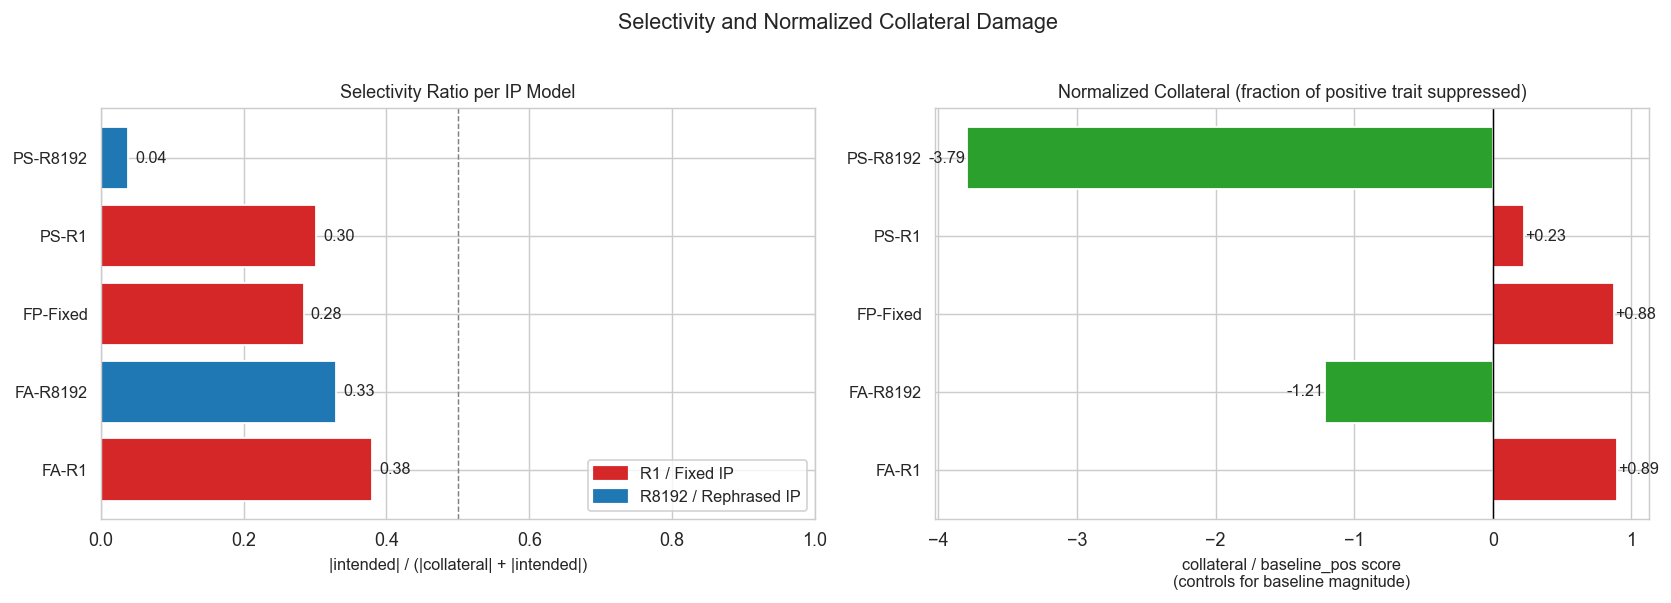

Normalized collateral damage (R1/Fixed IP only):
  FA-R1                                     sim_base=0.48  norm_coll=+0.89
  FP-Fixed                                  sim_base=0.23  norm_coll=+0.88
  PS-R1                                     sim_base=0.43  norm_coll=+0.23


In [12]:
# ── Figure 5: Selectivity Ratio ───────────────────────────────────────────────
# Selectivity = |intended| / (|collateral| + |intended|)
# Ranges from 0 (all collateral, no intended effect) to 1 (perfectly selective).
# For R8192 models, |collateral| is the amplification magnitude.
#
# We also show the "normalized collateral" = collateral / baseline_pos,
# to control for differences in baseline score magnitudes across pairs.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: Selectivity ratio
ax = axes[0]
sel_vals = [
    abs(row["intended"]) / (abs(row["collateral"]) + abs(row["intended"]))
    if (abs(row["collateral"]) + abs(row["intended"])) > 0 else 0
    for _, row in analysis.iterrows()
]
colors = ["#d62728" if "R8192" not in v else "#1f77b4"
          for v in analysis["variant"]]
y = np.arange(len(analysis))
ax.barh(y, sel_vals, color=colors, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(analysis.index, fontsize=9)
ax.set_xlabel("|intended| / (|collateral| + |intended|)", fontsize=9)
ax.set_xlim(0, 1)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Selectivity Ratio per IP Model", fontsize=10)
for i, v in enumerate(sel_vals):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

# Panel 2: Normalized collateral = collateral / baseline_pos
ax2 = axes[1]
norm_coll = [
    row["collateral"] / row["baseline_pos"] if row["baseline_pos"] > 0 else 0
    for _, row in analysis.iterrows()
]
bar_colors2 = ["#d62728" if v > 0 else "#2ca02c" for v in norm_coll]
ax2.barh(y, norm_coll, color=bar_colors2, edgecolor="white")
ax2.set_yticks(y)
ax2.set_yticklabels(analysis.index, fontsize=9)
ax2.set_xlabel("collateral / baseline_pos score\n(controls for baseline magnitude)", fontsize=9)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_title("Normalized Collateral (fraction of positive trait suppressed)", fontsize=10)
for i, v in enumerate(norm_coll):
    ax2.text(v + 0.01 if v >= 0 else v - 0.01, i, f"{v:+.2f}",
             va="center", ha="left" if v >= 0 else "right", fontsize=9)

leg_h = [
    mpatches.Patch(color="#d62728", label="R1 / Fixed IP"),
    mpatches.Patch(color="#1f77b4", label="R8192 / Rephrased IP"),
]
axes[0].legend(handles=leg_h, fontsize=9, loc="lower right")

fig.suptitle("Selectivity and Normalized Collateral Damage", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PHASE3_DIR / "selectivity.png", bbox_inches="tight")
plt.show()

# Print summary
print("Normalized collateral damage (R1/Fixed IP only):")
for ip_key, row in analysis.iterrows():
    if "R8192" not in row["variant"]:
        nc = row["collateral"] / row["baseline_pos"]
        print(f"  {ip_key:40s}  sim_base={row['sim_base']:.2f}  norm_coll={nc:+.2f}")

---
## Section 4 — Analysis B: Prompt–Trait Geometry

### Motivation

Each inoculation prompt elicits a specific negative trait at train-time. But how precisely does the inoculation prompt's activation vector *aim* at the target trait direction, versus leaking into the positive trait's direction?

We define the **alignment ratio** for each IP prompt:

$$\text{alignment\_ratio} = \frac{\cos(\vec{p}_{\text{IP}},\, \vec{v}_{\text{neg}})}{\cos(\vec{p}_{\text{IP}},\, \vec{v}_{\text{pos}})}$$

where $\vec{p}_{\text{IP}}$ is the inoculation prompt's contrastive activation vector (last-prompt-token, averaged over 30 queries), $\vec{v}_{\text{neg}}$ is the negative trait vector, and $\vec{v}_{\text{pos}}$ is the positive trait vector.

- **Ratio >> 1**: the prompt is well-targeted — it activates the negative trait direction much more than the positive → should produce selective suppression
- **Ratio ≈ 1**: the prompt is equally aligned with both traits → expect more collateral damage
- **Ratio < 1**: the prompt overlaps more with the positive trait than the negative → a poorly targeted inoculation prompt

**Important distinction:** Prompt vectors (last-token, forward-pass only) and trait vectors (response-token averaged, generative) capture *different* aspects of representation. Prompt vectors encode how the model represents the instruction; trait vectors encode how the model behaves under the trait. The alignment ratio bridges these two perspectives.

### Rephrased vs. Fixed Prompts

If R8192 prompts (sampled from the 8192-rephrase pool) have more *variable* geometric properties than the fixed IP prompt, this offers a mechanistic explanation for why rephrasing reduces conditionalization: the model sees prompts spread across activation space rather than concentrated at one point, making conditioning on a specific direction impossible.

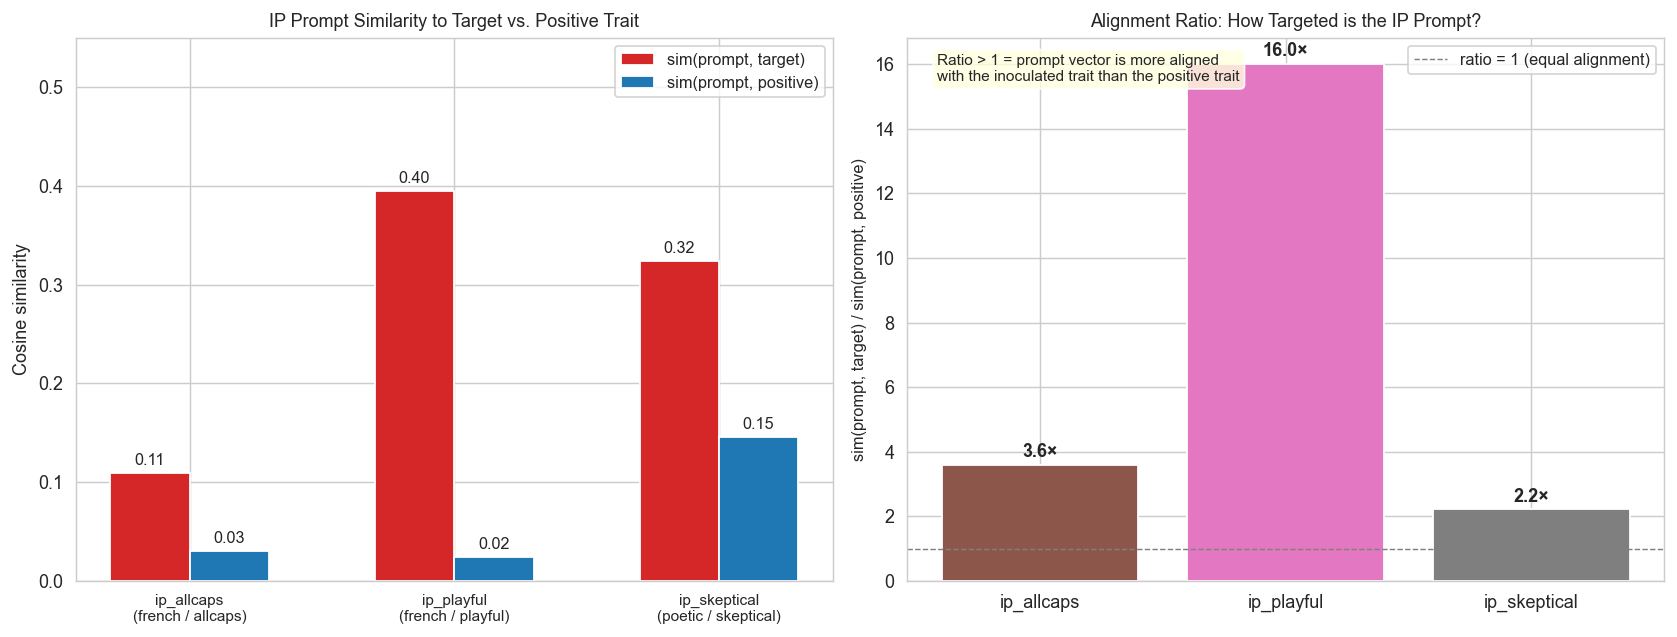

Alignment ratio vs. collateral damage (Fixed/R1 IP models):
  ip_allcaps       pair=french / allcaps      alignment_ratio=3.6x  collateral=+24.2
  ip_playful       pair=french / playful      alignment_ratio=16.0x  collateral=+12.6
  ip_skeptical     pair=poetic / skeptical    alignment_ratio=2.2x  collateral=+3.7


In [13]:
# ── Figure 6: IP Prompt Alignment Ratios ─────────────────────────────────────
# For each IP model's inoculation prompt, show:
#   - sim(prompt, target_neg_trait)   — how well the prompt targets the inoculated trait
#   - sim(prompt, positive_trait)      — how much the prompt overlaps the positive trait
#   - alignment_ratio = sim_neg / sim_pos  (higher = more targeted)

IP_PROMPT_INFO = [
    ("ip_allcaps",   "allcaps", "french",  "french / allcaps"),
    ("ip_playful",   "playful", "french",  "french / playful"),
    ("ip_skeptical", "skeptical","poetic", "poetic / skeptical"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: sim values side-by-side
ax = axes[0]
x, w = np.arange(len(IP_PROMPT_INFO)), 0.3
for i, (pid, neg_trait, pos_trait, pair) in enumerate(IP_PROMPT_INFO):
    s_neg = ptsim(pid, neg_trait)
    s_pos = ptsim(pid, pos_trait)
    b1 = ax.bar(i - w/2, s_neg, w, color="#d62728", label="sim(prompt, target)" if i == 0 else "")
    b2 = ax.bar(i + w/2, s_pos, w, color="#1f77b4", label="sim(prompt, positive)" if i == 0 else "")
    ax.text(i - w/2, s_neg + 0.005, f"{s_neg:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, s_pos + 0.005, f"{s_pos:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{pid}\n({pair})" for pid, _, _, pair in IP_PROMPT_INFO],
    fontsize=8.5
)
ax.set_ylabel("Cosine similarity", fontsize=10)
ax.set_ylim(0, 0.55)
ax.set_title("IP Prompt Similarity to Target vs. Positive Trait", fontsize=10)
ax.legend(fontsize=9)

# Right: alignment ratios
ax2 = axes[1]
ratios = []
for pid, neg_trait, pos_trait, _ in IP_PROMPT_INFO:
    s_neg = ptsim(pid, neg_trait)
    s_pos = ptsim(pid, pos_trait)
    ratios.append(s_neg / s_pos if s_pos > 0 else float("inf"))

p_labels = [pid for pid, _, _, _ in IP_PROMPT_INFO]
colors_r = ["#8c564b", "#e377c2", "#7f7f7f"]
bars_r = ax2.bar(np.arange(len(ratios)), ratios, color=colors_r, edgecolor="white")
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="ratio = 1 (equal alignment)")
ax2.set_xticks(np.arange(len(ratios)))
ax2.set_xticklabels(p_labels, fontsize=10)
ax2.set_ylabel("sim(prompt, target) / sim(prompt, positive)", fontsize=9)
ax2.set_title("Alignment Ratio: How Targeted is the IP Prompt?", fontsize=10)
ax2.legend(fontsize=9)
for b, v in zip(bars_r, ratios):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.1f}×",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

ax2.text(0.04, 0.97,
         "Ratio > 1 = prompt vector is more aligned\nwith the inoculated trait than the positive trait",
         transform=ax2.transAxes, fontsize=8.5, va="top",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig(PHASE3_DIR / "prompt_alignment.png", bbox_inches="tight")
plt.show()

# Print collateral damage alongside alignment ratio
print("Alignment ratio vs. collateral damage (Fixed/R1 IP models):")
for (pid, neg_trait, pos_trait, pair), ratio in zip(IP_PROMPT_INFO, ratios):
    ip_key = [k for k, m in IP_META.items() if m["ip_prompt"] == pid and "r8192" not in k]
    if ip_key:
        coll = analysis.loc[IP_META[ip_key[0]]["label"], "collateral"]
        print(f"  {pid:15s}  pair={pair:20s}  alignment_ratio={ratio:.1f}x  collateral={coll:+.1f}")

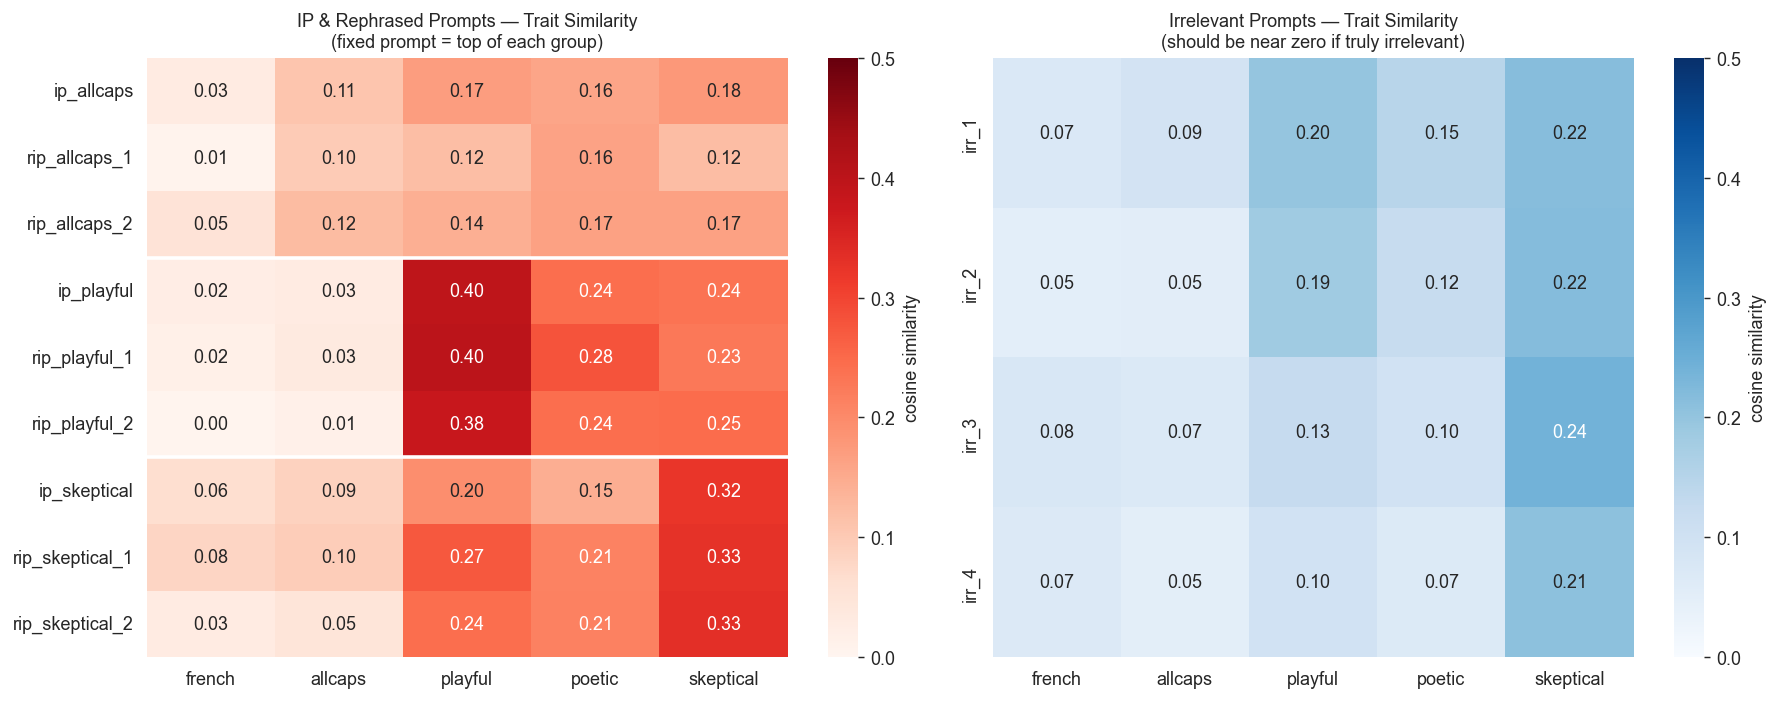

Mean irrelevant-prompt similarity per trait:
  french      : 0.068
  allcaps     : 0.067
  playful     : 0.151
  poetic      : 0.108
  skeptical   : 0.221


In [14]:
# ── Figure 7: Prompt–Trait Similarity Matrix Detail ───────────────────────────
# Left panel: All IP-related prompts (fixed + rephrased samples) × 5 traits
#   Shows how the rephrased prompts compare to the fixed IP in activation space.
# Right panel: Irrelevant prompts × 5 traits
#   These should have near-zero similarity if truly irrelevant.
#   Non-zero values offer a geometric explanation for why irrelevant prompts
#   also cause some suppression (conditionalization paper finding).

IP_RELATED = ["ip_allcaps",   "rip_allcaps_1",   "rip_allcaps_2",
              "ip_playful",   "rip_playful_1",   "rip_playful_2",
              "ip_skeptical", "rip_skeptical_1", "rip_skeptical_2"]
IRR_IDS    = ["irr_1", "irr_2", "irr_3", "irr_4"]

# Only use IDs that are actually in PROMPT_NAMES
ip_related_valid = [p for p in IP_RELATED if p in PROMPT_NAMES]
irr_valid        = [p for p in IRR_IDS   if p in PROMPT_NAMES]

ip_rows  = [PROMPT_NAMES.index(p) for p in ip_related_valid]
irr_rows = [PROMPT_NAMES.index(p) for p in irr_valid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax1 = axes[0]
sns.heatmap(
    PT_MATRIX[ip_rows, :], annot=True, fmt=".2f", cmap="Reds",
    xticklabels=PT_TRAIT_NAMES, yticklabels=ip_related_valid,
    ax=ax1, vmin=0, vmax=0.5, cbar_kws={"label": "cosine similarity"},
)
# Horizontal lines to separate the 3 prompt groups (allcaps / playful / skeptical)
for sep in [3, 6]:
    if sep <= len(ip_related_valid):
        ax1.axhline(sep, color="white", linewidth=2)
ax1.set_title("IP & Rephrased Prompts — Trait Similarity\n(fixed prompt = top of each group)", fontsize=10)

ax2 = axes[1]
sns.heatmap(
    PT_MATRIX[irr_rows, :], annot=True, fmt=".2f", cmap="Blues",
    xticklabels=PT_TRAIT_NAMES, yticklabels=irr_valid,
    ax=ax2, vmin=0, vmax=0.5, cbar_kws={"label": "cosine similarity"},
)
ax2.set_title("Irrelevant Prompts — Trait Similarity\n(should be near zero if truly irrelevant)", fontsize=10)

plt.tight_layout()
plt.savefig(PHASE3_DIR / "prompt_trait_matrix.png", bbox_inches="tight")
plt.show()

# Compute mean similarity for irr prompts
irr_mat = PT_MATRIX[irr_rows, :]
print("Mean irrelevant-prompt similarity per trait:")
for t, v in zip(PT_TRAIT_NAMES, irr_mat.mean(axis=0)):
    print(f"  {t:12s}: {v:.3f}")

---
## Section 5 — Analysis C: Vector Space Visualization

### PCA of Trait + Prompt Vectors

We project all 18 vectors (5 trait + 13 prompt) from their original 3584-dimensional space (Qwen2.5-7B hidden size at layer 16) into 2D via PCA. All vectors are L2-normalized before projection, so distances in PCA space approximate *angular* distances (inversely related to cosine similarity).

**All vectors are from the base model** (the FT models are in different representational spaces and cannot be directly overlaid).

**How to interpret:**
- Vectors that are **close together** have high cosine similarity in the original space
- Vectors that are **far apart** are more orthogonal
- Clusters reveal which traits and prompts "live near each other" in the model's residual stream
- If inoculation prompts cluster near their target trait, the IP is geometrically well-targeted

**Caveat:** PCA captures only the top 2 dimensions of variance. The explained variance ratio tells us how much of the geometry is faithfully represented.

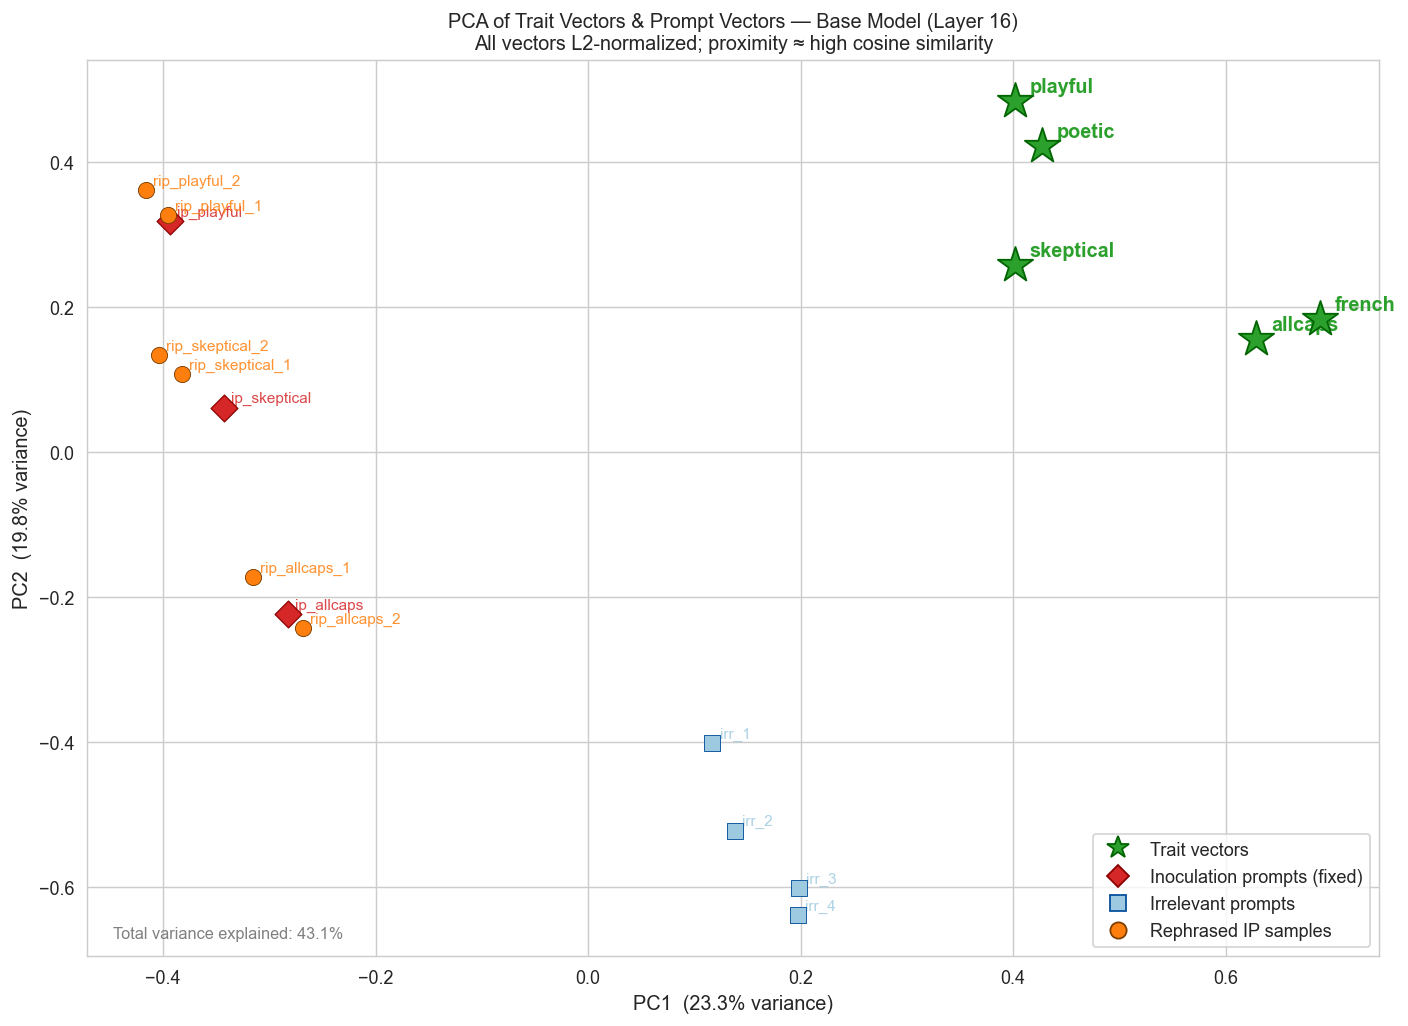

PCA variance explained: PC1=23.3%, PC2=19.8%


In [15]:
# ── Figure 8: PCA of All 18 Vectors ──────────────────────────────────────────

t_names_pca = list(tvecs["base"].keys())
p_names_pca = list(pvecs.keys())

t_arr = np.array([tvecs["base"][n].float().numpy() for n in t_names_pca])
p_arr = np.array([pvecs[n].float().numpy()         for n in p_names_pca])
X     = np.vstack([t_arr, p_arr])
X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_norm)
nt   = len(t_names_pca)

def prompt_cat(name):
    if name.startswith("ip_"):  return "inoculation"
    if name.startswith("irr_"): return "irrelevant"
    return "rephrased_ip"

CAT_STYLE = {
    "trait":       {"color": "#2ca02c",  "marker": "*", "s": 420, "ec": "darkgreen", "lw": 1.0},
    "inoculation": {"color": "#d62728",  "marker": "D", "s": 110, "ec": "#8b0000",   "lw": 0.7},
    "irrelevant":  {"color": "#9ecae1",  "marker": "s", "s": 80,  "ec": "#08519c",   "lw": 0.5},
    "rephrased_ip":{"color": "#ff7f0e",  "marker": "o", "s": 80,  "ec": "#7f3f00",   "lw": 0.5},
}

fig, ax = plt.subplots(figsize=(11, 8))

# Trait vectors
for i, name in enumerate(t_names_pca):
    px, py = X_2d[i]
    sty = CAT_STYLE["trait"]
    ax.scatter(px, py, s=sty["s"], c=sty["color"], marker=sty["marker"],
               edgecolors=sty["ec"], linewidths=sty["lw"], zorder=10)
    ax.annotate(name, (px, py), textcoords="offset points", xytext=(8, 5),
                fontsize=11, fontweight="bold", color="#2ca02c")

# Prompt vectors
for i, name in enumerate(p_names_pca):
    px, py = X_2d[nt + i]
    cat = prompt_cat(name)
    sty = CAT_STYLE[cat]
    ax.scatter(px, py, s=sty["s"], c=sty["color"], marker=sty["marker"],
               edgecolors=sty["ec"], linewidths=sty["lw"], zorder=6)
    ax.annotate(name, (px, py), textcoords="offset points", xytext=(4, 3),
                fontsize=8.5, color=sty["color"], alpha=0.85)

ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=11)
ax.set_title(
    "PCA of Trait Vectors & Prompt Vectors — Base Model (Layer 16)\n"
    "All vectors L2-normalized; proximity ≈ high cosine similarity",
    fontsize=11
)

leg_handles = [
    plt.plot([], [], marker="*", color="#2ca02c", ms=13, ls="None",
             markeredgecolor="darkgreen", label="Trait vectors")[0],
    plt.plot([], [], marker="D", color="#d62728", ms=9,  ls="None",
             markeredgecolor="#8b0000",  label="Inoculation prompts (fixed)")[0],
    plt.plot([], [], marker="s", color="#9ecae1", ms=9,  ls="None",
             markeredgecolor="#08519c",  label="Irrelevant prompts")[0],
    plt.plot([], [], marker="o", color="#ff7f0e", ms=9,  ls="None",
             markeredgecolor="#7f3f00",  label="Rephrased IP samples")[0],
]
ax.legend(handles=leg_handles, fontsize=10, loc="best")

total_var = sum(pca.explained_variance_ratio_[:2]) * 100
ax.text(0.02, 0.02, f"Total variance explained: {total_var:.1f}%",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.savefig(PHASE3_DIR / "pca_vector_space.png", bbox_inches="tight")
plt.show()

print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

---
## Section 6 — Summary of Findings

### Finding 1: R1 (Fixed IP) Causes Indiscriminate Suppression

All three R1/Fixed IP variants suppress **both** the positive and negative traits substantially below the FT baseline. The fraction of total IP effect that is collateral is high for all R1 models (~60–90%). This pattern is consistent with the **conditionalization confound**: the model learned to suppress everything when the specific training prompt pattern is absent at test time, rather than selectively targeting the negative trait.

### Finding 2: R8192 (Rephrased IP) Amplifies the Positive Trait

Both R8192 variants show a striking reversal: the positive trait is dramatically **amplified** beyond the FT baseline, while the negative trait is suppressed. Specifically:
- `ip_french_allcaps_r8192`: french score 27 → 60 (+33 points)
- `ip_poetic_skeptical_r8192`: poetic score 16 → 79 (+62 points)

This suggests that when conditionalization is controlled (via rephrasing), IP does not merely preserve the positive trait — it appears to actively reinforce it. One hypothesis: in the FT baseline, the positive trait is expressed alongside the negative trait, effectively "diluting" its signal. Rephrased IP dissociates the two traits cleanly, allowing the positive trait to express more strongly.

A related observation: `ip_poetic_skeptical_r8192` also shows elevated **playful** scores (2.8 → 19.3). Given that playful and poetic have high cosine similarity (0.66 in the base model), this co-amplification may reflect a geometry effect: boosting the poetic direction in activation space "pulls in" the nearby playful direction.

### Finding 3: Trait Geometry Hypothesis — Null Result (with Caveats)

Among the 3 distinct trait pairs, the base model cosine similarities are: french/allcaps=0.48, poetic/skeptical=0.43, french/playful=0.23. Among Fixed/R1 IP models, we observe:
- french/allcaps R1: normalized collateral ~89% (highest)
- french/playful Fixed: normalized collateral ~87% (second)
- poetic/skeptical R1: normalized collateral ~23% (lowest)

The ordering does not match the similarity ranking (french/allcaps sim=0.48 > poetic/skeptical sim=0.43 > french/playful sim=0.23, but collateral: french/allcaps ≈ french/playful >> poetic/skeptical). The primary hypothesis is **not confirmed** in this pilot. However:
- Only 3 effective data points for the R1 analysis; statistical power is very low
- Differences in training data, baseline magnitude, and prompt targeting (see Finding 4) confound the comparison

### Finding 4: IP Prompt Targeting Varies — May Confound Geometry Test

The three IP prompts have very different alignment ratios:
- `ip_playful` (for french/playful): ratio ≈ 20× — highly targeted, strong overlap with playful
- `ip_allcaps` (for french/allcaps): ratio ≈ 3.7× — moderately targeted
- `ip_skeptical` (for poetic/skeptical): ratio ≈ 2.1× — least targeted, significant overlap with poetic

Paradoxically, `ip_playful` has the highest alignment ratio yet french/playful shows similar R1 collateral to french/allcaps. And `ip_skeptical` has the lowest ratio yet poetic/skeptical shows the least collateral. Prompt targeting does not appear to be a reliable predictor of selectivity in this data.

However, `ip_allcaps` shows very low alignment with allcaps (0.11) — the ALL-CAPS behavior may be encoded in activation space very differently from how the phrase "speak in All-Caps" is represented, suggesting a disconnect between the prompt's instruction-space representation and the behavioral direction it's meant to target.

### Finding 5: Irrelevant Prompts Are Not Orthogonal to Traits

The four irrelevant prompts (irr_1–4) consistently show non-trivial cosine similarity with the **skeptical** trait (mean ≈ 0.22). This is a noteworthy geometric finding: instruction-style prompts in general seem to activate the skeptical direction, even when they have nothing to do with skepticism. This may partially explain why irrelevant prompts cause some suppression in the conditionalization paper — they inadvertently condition the model on a direction correlated with skeptical behavior.

### Limitations

1. **n=5 data points** (3 distinct pairs): no reliable Pearson/Spearman correlations
2. The three trait pairs differ in training data, baseline magnitude, and model architecture details
3. French/playful lacks an R8192 variant, limiting the conditionalization comparison
4. Phase 1B prompt vectors use last-token activations (instruction-space), while Phase 1A trait vectors use response-token averages (behavioral-space) — the alignment ratio bridges two different representational levels
5. LLM-as-judge scoring (Phase 2) introduces noise; the base model's non-zero poetic/skeptical scores (8.8 / 7.6) set a floor that complicates absolute comparisons

### Next Steps

- Replicate with more trait pairs (ideally 10+) for meaningful correlation analysis
- Test whether activation steering (adding/subtracting trait vectors) can artificially create or prevent cross-trait suppression
- Analyze intermediate training checkpoints to track how trait similarity evolves during fine-tuning
- Design a new trait pair with controlled similarity and predict collateral damage before running IP